In [37]:
import pandas as pd
import numpy as np
import matplotlib as plt
from matplotlib import pyplot 

In [38]:
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-Coursera/laptop_pricing_dataset_mod1.csv"

In [39]:
df = pd.read_csv(url, header = 0)

In [40]:
df.head()

,Unnamed: 0,Manufacturer,Category,Screen,GPU,OS,CPU_core,Screen_Size_cm,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_kg,Price
0,0,Acer,4,IPS Panel,2,1,5,35.560,1.6,8,256,1.60,978
1,1,Dell,3,Full HD,1,1,3,39.624,2.0,4,256,2.20,634
2,2,Dell,3,Full HD,1,1,7,39.624,2.7,8,256,2.20,946
3,3,Dell,4,IPS Panel,2,1,5,33.782,1.6,8,128,1.22,1244
4,4,HP,4,Full HD,2,1,7,39.624,1.8,8,256,1.91,837


In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 238 entries, 0 to 237
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      238 non-null    int64  
 1   Manufacturer    238 non-null    object 
 2   Category        238 non-null    int64  
 3   Screen          238 non-null    object 
 4   GPU             238 non-null    int64  
 5   OS              238 non-null    int64  
 6   CPU_core        238 non-null    int64  
 7   Screen_Size_cm  234 non-null    float64
 8   CPU_frequency   238 non-null    float64
 9   RAM_GB          238 non-null    int64  
 10  Storage_GB_SSD  238 non-null    int64  
 11  Weight_kg       233 non-null    float64
 12  Price           238 non-null    int64  
dtypes: float64(3), int64(8), object(2)
memory usage: 24.3+ KB


In [42]:
df['Screen_Size_cm'] = np.round(df['Screen_Size_cm'],2)

In [43]:
df.head()

,Unnamed: 0,Manufacturer,Category,Screen,GPU,OS,CPU_core,Screen_Size_cm,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_kg,Price
0,0,Acer,4,IPS Panel,2,1,5,35.56,1.6,8,256,1.60,978
1,1,Dell,3,Full HD,1,1,3,39.62,2.0,4,256,2.20,634
2,2,Dell,3,Full HD,1,1,7,39.62,2.7,8,256,2.20,946
3,3,Dell,4,IPS Panel,2,1,5,33.78,1.6,8,128,1.22,1244
4,4,HP,4,Full HD,2,1,7,39.62,1.8,8,256,1.91,837


In [44]:
missing_data = df.isnull()
missing_data

,Unnamed: 0,Manufacturer,Category,Screen,GPU,OS,CPU_core,Screen_Size_cm,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_kg,Price
0,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
233,False,False,False,False,False,False,False,False,False,False,False,False,False
234,False,False,False,False,False,False,False,False,False,False,False,False,False
235,False,False,False,False,False,False,False,False,False,False,False,False,False
236,False,False,False,False,False,False,False,False,False,False,False,False,False


In [45]:
for column in missing_data.columns.values.tolist():
    print(column)
    print(missing_data[column].value_counts())
    print("----")

Unnamed: 0
Unnamed: 0
False    238
Name: count, dtype: int64
----
Manufacturer
Manufacturer
False    238
Name: count, dtype: int64
----
Category
Category
False    238
Name: count, dtype: int64
----
Screen
Screen
False    238
Name: count, dtype: int64
----
GPU
GPU
False    238
Name: count, dtype: int64
----
OS
OS
False    238
Name: count, dtype: int64
----
CPU_core
CPU_core
False    238
Name: count, dtype: int64
----
Screen_Size_cm
Screen_Size_cm
False    234
True       4
Name: count, dtype: int64
----
CPU_frequency
CPU_frequency
False    238
Name: count, dtype: int64
----
RAM_GB
RAM_GB
False    238
Name: count, dtype: int64
----
Storage_GB_SSD
Storage_GB_SSD
False    238
Name: count, dtype: int64
----
Weight_kg
Weight_kg
False    233
True       5
Name: count, dtype: int64
----
Price
Price
False    238
Name: count, dtype: int64
----


In [46]:
df["Weight_kg"] = df["Weight_kg"].fillna(df["Weight_kg"].mean())

In [48]:
freq_size = df['Screen_Size_cm'].value_counts().idxmax()
freq_size

np.float64(39.62)

In [49]:
df['Screen_Size_cm']=df['Screen_Size_cm'].fillna(freq_size)

In [50]:
df['Screen_Size_cm']

0      35.56
1      39.62
2      39.62
3      33.78
4      39.62
       ...  
233    35.56
234    33.78
235    30.48
236    39.62
237    35.56
Name: Screen_Size_cm, Length: 238, dtype: float64

In [51]:
df[["Weight_kg","Screen_Size_cm"]] = df[["Weight_kg","Screen_Size_cm"]].astype("float")

In [52]:
df["Weight_kg"] = df["Weight_kg"]*2.205
df.rename(columns={'Weight_kg':'Weight_pounds'}, inplace=True)

# Data standardization: convert screen size from cm to inch
df["Screen_Size_cm"] = df["Screen_Size_cm"]/2.54
df.rename(columns={'Screen_Size_cm':'Screen_Size_inch'}, inplace=True)

In [53]:
df['CPU_frequency'] = df['CPU_frequency']/df['CPU_frequency'].max()

In [59]:
bins = np.linspace(min(df["Price"]),max(df["Price"]),4)

In [60]:
group_names = ['Low','Medium','High']
df["price-binned"] = pd.cut(df["Price"],bins, labels = group_names, include_lowest = True)

Text(0.5, 1.0, 'Price Bins')

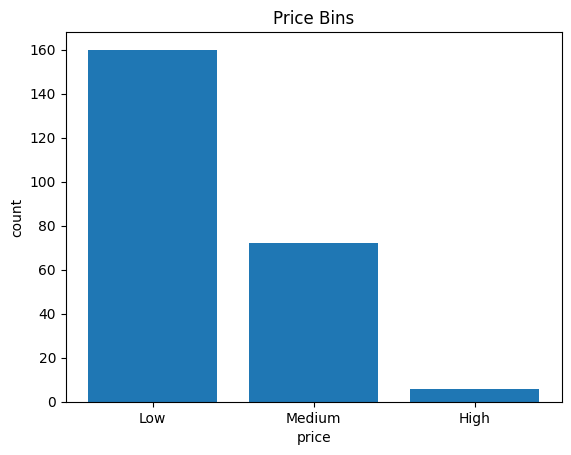

In [68]:
plt.pyplot.bar(group_names,df["price-binned"].value_counts())
plt.pyplot.xlabel('price')
plt.pyplot.ylabel('count')
plt.pyplot.title('Price Bins')

In [71]:
dummy_variable = pd.get_dummies(df["Screen"])
df = pd.concat([df,dummy_variable],axis = 1)

In [72]:
df.drop("Screen",axis = 1, inplace = True)

In [73]:
df.head()

,Unnamed: 0,Manufacturer,Category,GPU,OS,CPU_core,Screen_Size_inch,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_pounds,Price,price-binned,Full HD,IPS Panel
0,0,Acer,4,2,1,5,14.000000,0.551724,8,256,3.52800,978,Low,False,True
1,1,Dell,3,1,1,3,15.598425,0.689655,4,256,4.85100,634,Low,True,False
2,2,Dell,3,1,1,7,15.598425,0.931034,8,256,4.85100,946,Low,True,False
3,3,Dell,4,2,1,5,13.299213,0.551724,8,128,2.69010,1244,Low,False,True
4,4,HP,4,2,1,7,15.598425,0.620690,8,256,4.21155,837,Low,True,False
